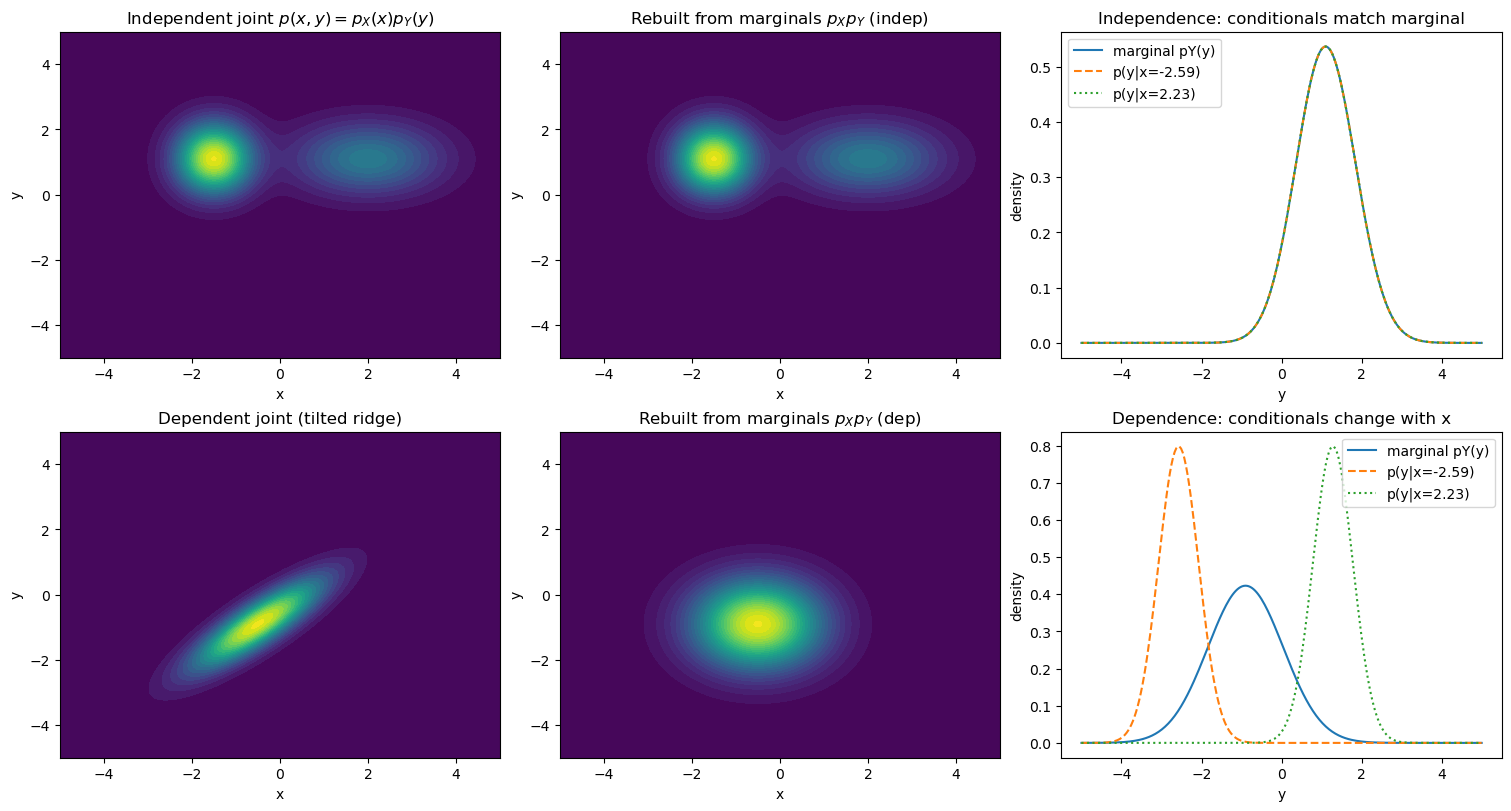

Sanity check (should be ~1):
  mass_indep = 1.0000000000000002
  mass_dep   = 1.0

How close is p(x,y) to pX(x)pY(y)? (smaller => more independent)
  indep L1 difference = 3.978045601623294e-16
  dep   L1 difference = 0.8783298324104657


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Example: Independence vs Dependence
# ============================================================

# Grid for x and y
x = np.linspace(-5, 5, 250)
y = np.linspace(-5, 5, 250)
X, Y = np.meshgrid(x, y)

dx = x[1] - x[0]
dy = y[1] - y[0]

# ------------------------------------------------------------
# 1) Independent joint: p(x,y) = pX(x) * pY(y)
# We'll make pX and pY non-Gaussian to keep it visually obvious.
# ------------------------------------------------------------

# Non-Gaussian pX: mixture of two 1D bumps
pX = 0.7 * np.exp(-((x + 1.5) ** 2) / 0.7) + 0.3 * np.exp(-((x - 2.0) ** 2) / 2.5)
pX = pX / (np.sum(pX) * dx)  # normalize so ∫ pX dx = 1

# Non-Gaussian pY: asymmetry added with a logistic factor
pY = np.exp(-((y - 1.0) ** 2) / 1.2) * (1.0 / (1.0 + np.exp(-(y + 0.5))))
pY = pY / (np.sum(pY) * dy)  # normalize so ∫ pY dy = 1

# Independent joint via outer product
Z_indep = np.outer(pY, pX)  # shape (len(y), len(x))
mass_indep = np.sum(Z_indep) * dx * dy  # should be ~1

# ------------------------------------------------------------
# 2) Dependent joint: build a tilted ridge so Y depends on X
# then normalize to make it a valid joint density.
# ------------------------------------------------------------
Z_dep = np.exp(-((X + 0.5) ** 2) / 2.0 - ((Y - (0.8 * X - 0.5)) ** 2) / 0.5)
Z_dep /= (np.sum(Z_dep) * dx * dy)
mass_dep = np.sum(Z_dep) * dx * dy  # should be ~1

# ------------------------------------------------------------
# Marginals for each case
# pX(x) = ∫ p(x,y) dy  ~ sum over y * dy
# pY(y) = ∫ p(x,y) dx  ~ sum over x * dx
# ------------------------------------------------------------
pX_indep = np.sum(Z_indep, axis=0) * dy
pY_indep = np.sum(Z_indep, axis=1) * dx

pX_dep = np.sum(Z_dep, axis=0) * dy
pY_dep = np.sum(Z_dep, axis=1) * dx

# Rebuild "independence-assumption" joint from marginals
Z_from_marg_indep = np.outer(pY_indep, pX_indep)
Z_from_marg_dep   = np.outer(pY_dep, pX_dep)

# ------------------------------------------------------------
# Conditional check: independence means p(y|x) = pY(y) for ALL x
# We'll compare conditionals at two different x values.
# ------------------------------------------------------------
ix1, ix2 = 60, 180  # two different x indices

condY_indep_1 = Z_indep[:, ix1] / pX_indep[ix1]
condY_indep_2 = Z_indep[:, ix2] / pX_indep[ix2]

condY_dep_1 = Z_dep[:, ix1] / pX_dep[ix1]
condY_dep_2 = Z_dep[:, ix2] / pX_dep[ix2]

# ------------------------------------------------------------
# Plots (contours + conditional vs marginal)
# ------------------------------------------------------------
fig, axs = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)

axs[0, 0].contourf(X, Y, Z_indep, levels=30)
axs[0, 0].set_title("Independent joint $p(x,y)=p_X(x)p_Y(y)$")
axs[0, 0].set_xlabel("x"); axs[0, 0].set_ylabel("y")

axs[0, 1].contourf(X, Y, Z_from_marg_indep, levels=30)
axs[0, 1].set_title("Rebuilt from marginals $p_X p_Y$ (indep)")
axs[0, 1].set_xlabel("x"); axs[0, 1].set_ylabel("y")

axs[0, 2].plot(y, pY_indep, label="marginal pY(y)")
axs[0, 2].plot(y, condY_indep_1, '--', label=f"p(y|x={x[ix1]:.2f})")
axs[0, 2].plot(y, condY_indep_2, ':',  label=f"p(y|x={x[ix2]:.2f})")
axs[0, 2].set_title("Independence: conditionals match marginal")
axs[0, 2].set_xlabel("y"); axs[0, 2].set_ylabel("density")
axs[0, 2].legend()

axs[1, 0].contourf(X, Y, Z_dep, levels=30)
axs[1, 0].set_title("Dependent joint (tilted ridge)")
axs[1, 0].set_xlabel("x"); axs[1, 0].set_ylabel("y")

axs[1, 1].contourf(X, Y, Z_from_marg_dep, levels=30)
axs[1, 1].set_title("Rebuilt from marginals $p_X p_Y$ (dep)")
axs[1, 1].set_xlabel("x"); axs[1, 1].set_ylabel("y")

axs[1, 2].plot(y, pY_dep, label="marginal pY(y)")
axs[1, 2].plot(y, condY_dep_1, '--', label=f"p(y|x={x[ix1]:.2f})")
axs[1, 2].plot(y, condY_dep_2, ':',  label=f"p(y|x={x[ix2]:.2f})")
axs[1, 2].set_title("Dependence: conditionals change with x")
axs[1, 2].set_xlabel("y"); axs[1, 2].set_ylabel("density")
axs[1, 2].legend()

plt.show()

print("Sanity check (should be ~1):")
print("  mass_indep =", mass_indep)
print("  mass_dep   =", mass_dep)

# Quantify mismatch between true joint and pX*pY
err_indep = np.sum(np.abs(Z_indep - Z_from_marg_indep)) * dx * dy
err_dep   = np.sum(np.abs(Z_dep   - Z_from_marg_dep))   * dx * dy

print("\nHow close is p(x,y) to pX(x)pY(y)? (smaller => more independent)")
print("  indep L1 difference =", err_indep)
print("  dep   L1 difference =", err_dep)
